Training rows : 444
Test rows     : 27

--- Time Series Cross Validation Results ---
Fold 1  |  Train: 74  |  Val: 74  |  MAPE: 9.76%  |  MAE: 1190.34  |  R²: 0.0755
Fold 2  |  Train: 148  |  Val: 74  |  MAPE: 22.13%  |  MAE: 3239.78  |  R²: -6.5425
Fold 3  |  Train: 222  |  Val: 74  |  MAPE: 11.44%  |  MAE: 1991.38  |  R²: -2.2782
Fold 4  |  Train: 296  |  Val: 74  |  MAPE: 3.12%  |  MAE: 648.12  |  R²: 0.5139
Fold 5  |  Train: 370  |  Val: 74  |  MAPE: 13.97%  |  MAE: 2866.60  |  R²: -9.1289

Mean CV MAPE : 12.09%
Std  CV MAPE : 6.17%
Mean CV MAE  : 1987.24
Mean CV R²   : -3.4720
=== Date Alignment Check ===
Train dates match:
  Data  : 2023-12-01 00:00:00
  Forecast: 2023-12-01 00:00:00
Test dates match:
  Data  : 2024-01-01 00:00:00  →  2026-03-01 00:00:00
  Forecast: 2024-01-01 00:00:00  →  2026-03-01 00:00:00

Train pred rows : 444  (expected 444)
Test pred rows  : 27   (expected 27)

Metric                       In-Sample   Out-Sample
MAPE (%)                          2.60      

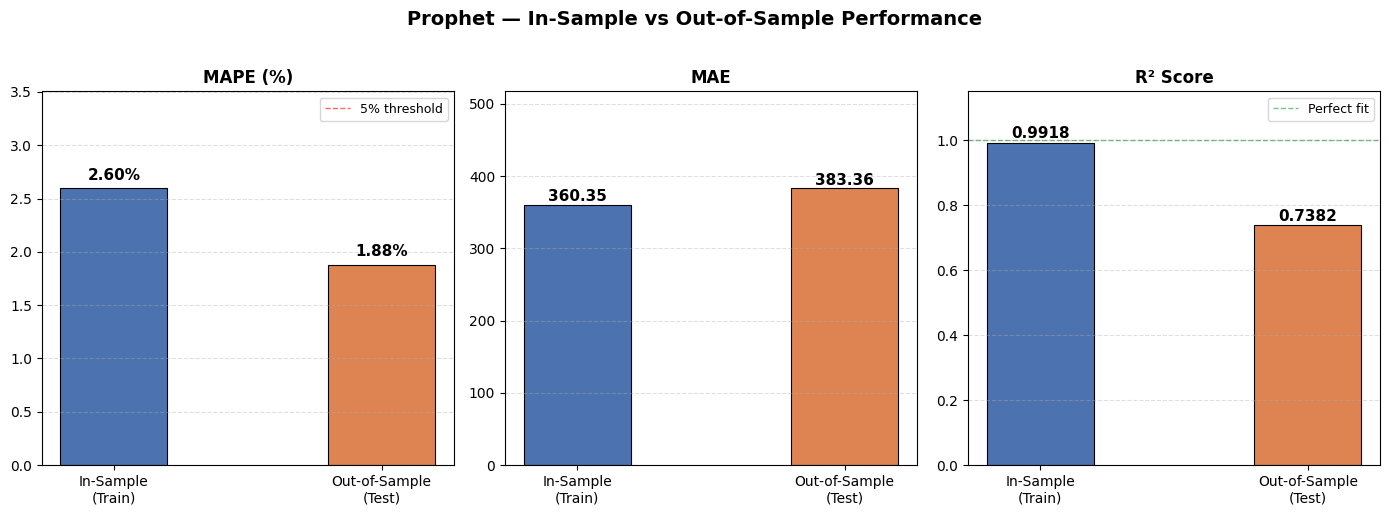

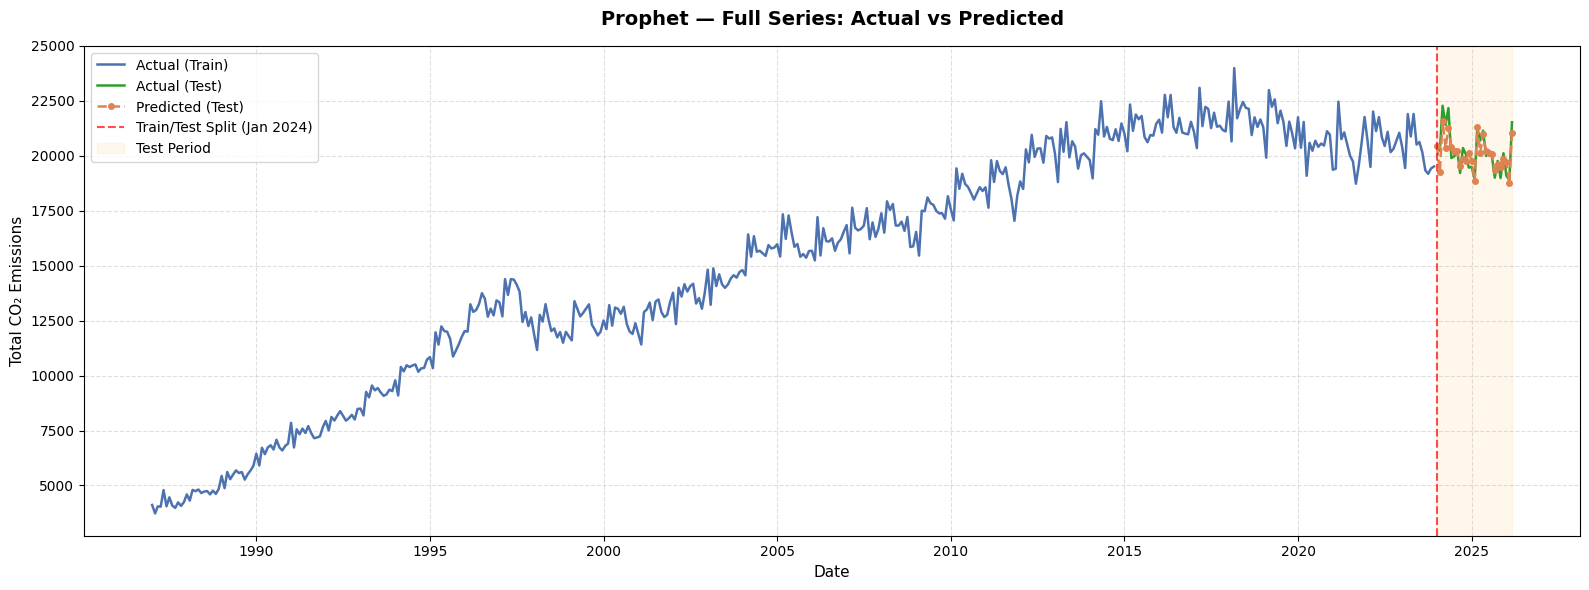

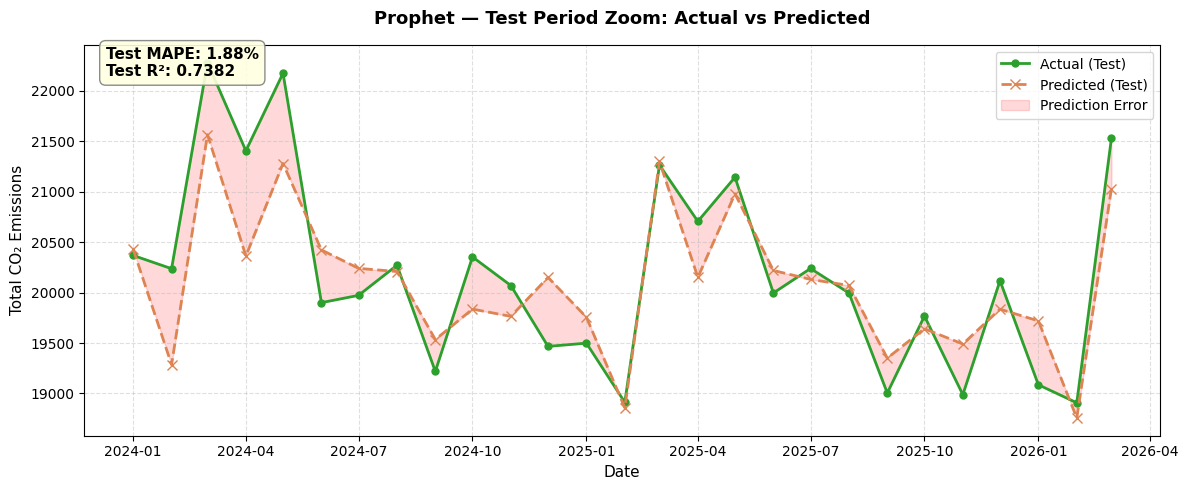

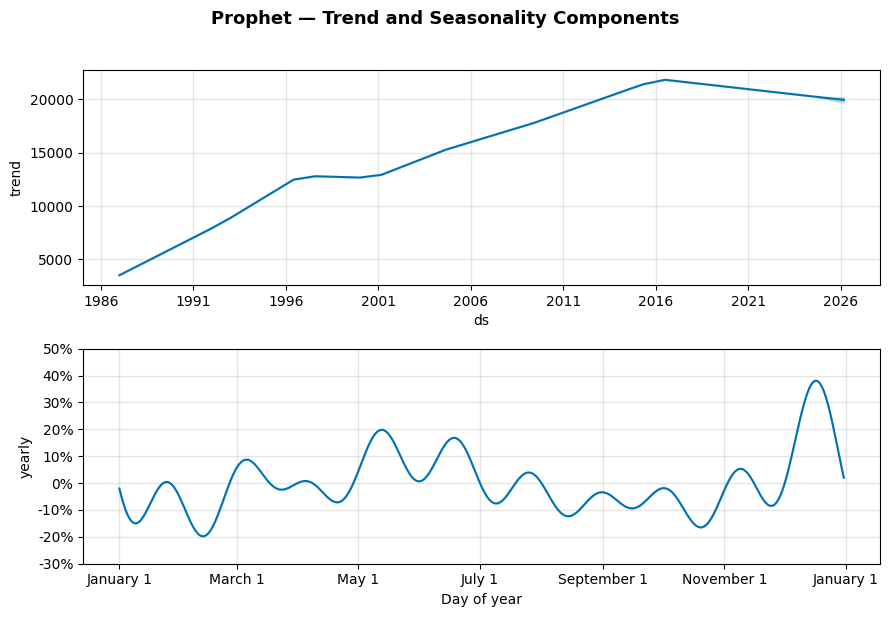

In [ ]:
# ============================================================
# PROPHET MODEL 
# Thailand CO2 Emissions Forecasting

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import (mean_absolute_percentage_error,
                             mean_absolute_error,
                             mean_squared_error,
                             r2_score)

# ============================================================
# STEP 1: LOAD AND PREPARE DATA
# Prophet requires exactly two columns: ds (date) and y (target)
# ============================================================

df = pd.read_csv('/content/co2_monthly_1987_2026_clean.csv')
monthly = df.groupby(['Year', 'Month'])['Total_CO2'].sum().reset_index()
monthly = monthly.sort_values(['Year', 'Month']).reset_index(drop=True)

# Create date column
monthly['ds'] = pd.to_datetime(monthly[['Year', 'Month']].assign(Day=1))
monthly['y']  = monthly['Total_CO2']

# ============================================================
# STEP 2: TRAIN / TEST SPLIT
# Same hard boundary as all other models — Jan 2024
# ============================================================

split_idx = monthly[(monthly['Year'] == 2024) & (monthly['Month'] == 1)].index[0]

train_df = monthly[['ds', 'y']].iloc[:split_idx].reset_index(drop=True)
test_df  = monthly[['ds', 'y']].iloc[split_idx:].reset_index(drop=True)

print(f"Training rows : {len(train_df)}")
print(f"Test rows     : {len(test_df)}")

# ============================================================
# STEP 3: TIME SERIES CROSS VALIDATION ON TRAINING DATA
# Prophet has its own built-in CV tool but we use manual
# TimeSeriesSplit here to stay consistent with LR and XGBoost
# ============================================================

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

cv_mape_scores = []
cv_mae_scores  = []
cv_r2_scores   = []

print("\n--- Time Series Cross Validation Results ---")

for fold, (tr_idx, val_idx) in enumerate(tscv.split(train_df)):

    X_tr_fold  = train_df.iloc[tr_idx].reset_index(drop=True)
    X_val_fold = train_df.iloc[val_idx].reset_index(drop=True)

    # Fit Prophet fresh each fold
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,   # monthly data, no weekly pattern
        daily_seasonality=False,
        seasonality_mode='multiplicative'  # better for CO2 which grows over time
    )
    m.fit(X_tr_fold)

    # Predict on validation fold dates
    future_val = m.make_future_dataframe(
        periods=len(X_val_fold), freq='MS'   # MS = Month Start
    )
    forecast_val = m.predict(future_val)

    # Extract predictions aligned to validation dates only
    preds_val = forecast_val.set_index('ds').loc[
        X_val_fold['ds'], 'yhat'
    ].values

    actual_val = X_val_fold['y'].values

    mape = mean_absolute_percentage_error(actual_val, preds_val) * 100
    mae  = mean_absolute_error(actual_val, preds_val)
    r2   = r2_score(actual_val, preds_val)

    cv_mape_scores.append(mape)
    cv_mae_scores.append(mae)
    cv_r2_scores.append(r2)

    print(f"Fold {fold+1}  |  Train: {len(X_tr_fold)}  |  Val: {len(X_val_fold)}  "
          f"|  MAPE: {mape:.2f}%  |  MAE: {mae:.2f}  |  R²: {r2:.4f}")

print(f"\nMean CV MAPE : {np.mean(cv_mape_scores):.2f}%")
print(f"Std  CV MAPE : {np.std(cv_mape_scores):.2f}%")
print(f"Mean CV MAE  : {np.mean(cv_mae_scores):.2f}")
print(f"Mean CV R²   : {np.mean(cv_r2_scores):.4f}")

# ============================================================
# STEP 4: FINAL MODEL — FIT ON FULL TRAINING DATA
# ============================================================

final_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
final_prophet.fit(train_df)

# ============================================================
# STEP 5: PREDICT ON TEST SET
# ============================================================

# Build future dataframe for ONLY the test period
# periods = number of test months beyond the training end
future_test_only = final_prophet.make_future_dataframe(
    periods=len(test_df), freq='MS'
)

# Get full forecast
forecast_full = final_prophet.predict(future_test_only)

# Split forecast into train and test portions explicitly
# by position, not by date matching
forecast_train = forecast_full.iloc[:len(train_df)]
forecast_test  = forecast_full.iloc[len(train_df):]

train_preds = forecast_train['yhat'].values
test_preds  = forecast_test['yhat'].values

# Verify date alignment before trusting any number
print("=== Date Alignment Check ===")
print("Train dates match:")
print(f"  Data  : {train_df['ds'].iloc[-1]}")
print(f"  Forecast: {forecast_train['ds'].iloc[-1]}")

print("Test dates match:")
print(f"  Data  : {test_df['ds'].iloc[0]}  →  {test_df['ds'].iloc[-1]}")
print(f"  Forecast: {forecast_test['ds'].iloc[0]}  →  {forecast_test['ds'].iloc[-1]}")

print(f"\nTrain pred rows : {len(train_preds)}  (expected {len(train_df)})")
print(f"Test pred rows  : {len(test_preds)}   (expected {len(test_df)})")

# ============================================================
# STEP 6: METRICS
# ============================================================

in_mape  = mean_absolute_percentage_error(train_df['y'], train_preds) * 100
out_mape = mean_absolute_percentage_error(test_df['y'],  test_preds)  * 100

in_mae   = mean_absolute_error(train_df['y'], train_preds)
out_mae  = mean_absolute_error(test_df['y'],  test_preds)

in_rmse  = np.sqrt(mean_squared_error(train_df['y'], train_preds))
out_rmse = np.sqrt(mean_squared_error(test_df['y'],  test_preds))

in_r2    = r2_score(train_df['y'], train_preds)
out_r2   = r2_score(test_df['y'],  test_preds)

print("\n" + "=" * 52)
print(f"{'Metric':<25} {'In-Sample':>12} {'Out-Sample':>12}")
print("=" * 52)
print(f"{'MAPE (%)':<25} {in_mape:>12.2f} {out_mape:>12.2f}")
print(f"{'MAE':<25} {in_mae:>12.2f} {out_mae:>12.2f}")
print(f"{'RMSE':<25} {in_rmse:>12.2f} {out_rmse:>12.2f}")
print(f"{'R²':<25} {in_r2:>12.4f} {out_r2:>12.4f}")
print("=" * 52)
print(f"{'MAPE Gap':<25} {out_mape - in_mape:>12.2f}%")

# ============================================================
# STEP 7: PLOT 1 — MAPE / MAE / R² BAR CHARTS
# ============================================================

labels = ['In-Sample\n(Train)', 'Out-of-Sample\n(Test)']
colors = ['#4C72B0', '#DD8452']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Prophet — In-Sample vs Out-of-Sample Performance',
             fontsize=14, fontweight='bold', y=1.02)

# MAPE
bars1 = axes[0].bar(labels, [in_mape, out_mape], color=colors,
                    width=0.4, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars1, [in_mape, out_mape]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_title('MAPE (%)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(in_mape, out_mape) * 1.35)
axes[0].axhline(y=5, color='red', linestyle='--', linewidth=1,
                alpha=0.6, label='5% threshold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# MAE
bars2 = axes[1].bar(labels, [in_mae, out_mae], color=colors,
                    width=0.4, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars2, [in_mae, out_mae]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.2f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[1].set_title('MAE', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, max(in_mae, out_mae) * 1.35)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# R²
bars3 = axes[2].bar(labels, [in_r2, out_r2], color=colors,
                    width=0.4, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars3, [in_r2, out_r2]):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[2].set_title('R² Score', fontsize=12, fontweight='bold')
axes[2].set_ylim(0, 1.15)
axes[2].axhline(y=1.0, color='green', linestyle='--',
                linewidth=1, alpha=0.5, label='Perfect fit')
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ============================================================
# STEP 8: PLOT 2 — FULL SERIES (TRAIN + TEST + PREDICTED)
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(train_df['ds'], train_df['y'],
        color='#4C72B0', linewidth=1.8, label='Actual (Train)')

ax.plot(test_df['ds'], test_df['y'],
        color='#2ca02c', linewidth=1.8, label='Actual (Test)')

ax.plot(test_df['ds'], test_preds,
        color='#DD8452', linewidth=1.8,
        linestyle='--', marker='o', markersize=4,
        label='Predicted (Test)')

split_date = test_df['ds'].iloc[0]
ax.axvline(x=split_date, color='red', linestyle='--',
           linewidth=1.5, alpha=0.7, label='Train/Test Split (Jan 2024)')
ax.axvspan(split_date, test_df['ds'].iloc[-1],
           alpha=0.08, color='orange', label='Test Period')

ax.set_title('Prophet — Full Series: Actual vs Predicted',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Total CO₂ Emissions', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 9: PLOT 3 — ZOOMED TEST PERIOD
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(test_df['ds'], test_df['y'],
        color='#2ca02c', linewidth=2,
        marker='o', markersize=5, label='Actual (Test)')

ax.plot(test_df['ds'], test_preds,
        color='#DD8452', linewidth=2,
        linestyle='--', marker='x', markersize=7,
        label='Predicted (Test)')

ax.fill_between(test_df['ds'], test_df['y'].values, test_preds,
                alpha=0.15, color='red', label='Prediction Error')

ax.annotate(f'Test MAPE: {out_mape:.2f}%\nTest R²: {out_r2:.4f}',
            xy=(0.02, 0.92), xycoords='axes fraction',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='lightyellow',
                      edgecolor='gray', alpha=0.9))

ax.set_title('Prophet — Test Period Zoom: Actual vs Predicted',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Total CO₂ Emissions', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 10: PLOT 4 — PROPHET COMPONENTS
# Shows trend and yearly seasonality separately
# ============================================================

fig = final_prophet.plot_components(forecast_full)
plt.suptitle('Prophet — Trend and Seasonality Components',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()